
Fitting Prophet on AAPL...
AAPL: loaded from cache (1883 rows)


17:58:09 - cmdstanpy - INFO - Chain [1] start processing
17:58:09 - cmdstanpy - INFO - Chain [1] done processing



  Prophet — AAPL
  RMSE               : 25.4714
  MAE                : 20.5958
  MAPE               : 7.41%
  Directional Acc.   : 41.9%


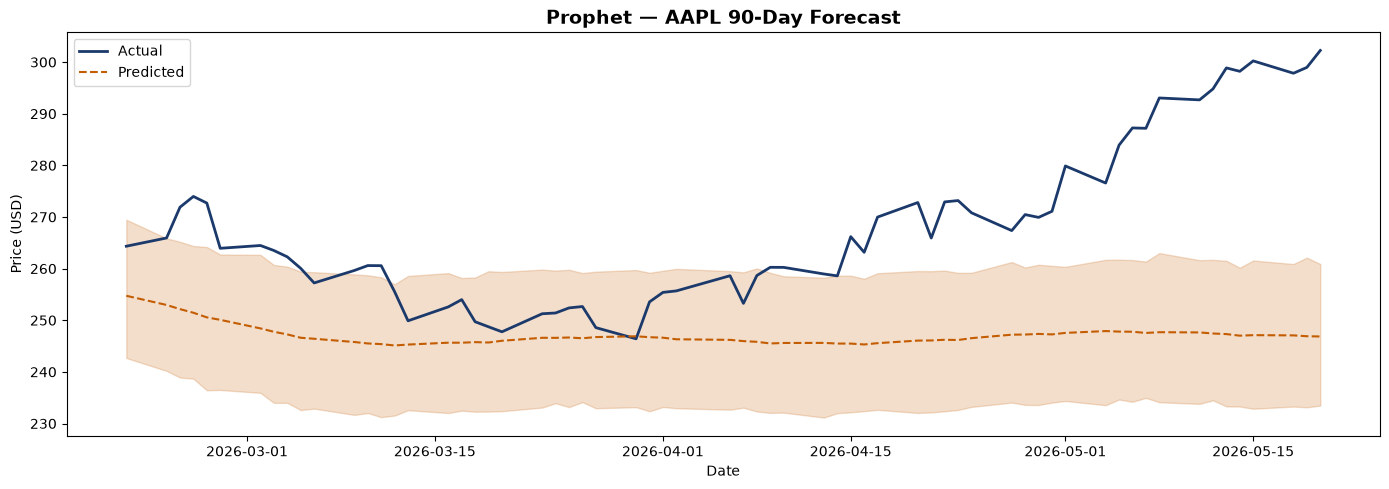

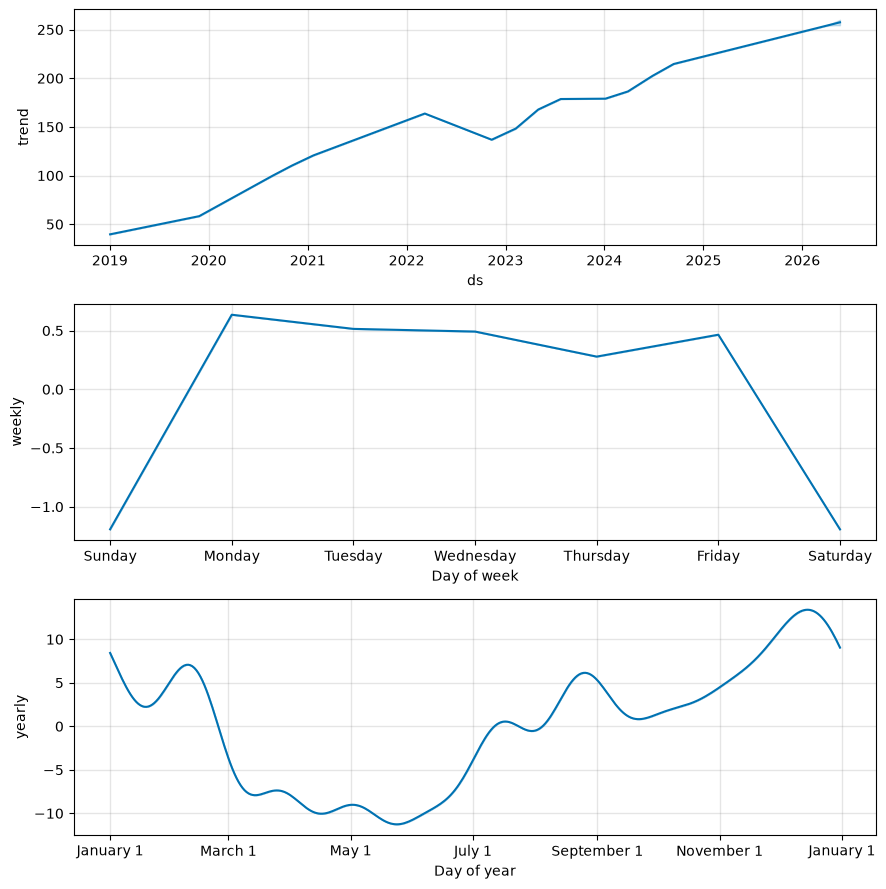


Fitting Prophet on MSFT...
MSFT: loaded from cache (1883 rows)


17:58:11 - cmdstanpy - INFO - Chain [1] start processing
17:58:12 - cmdstanpy - INFO - Chain [1] done processing



  Prophet — MSFT
  RMSE               : 93.2348
  MAE                : 91.5473
  MAPE               : 23.19%
  Directional Acc.   : 45.2%


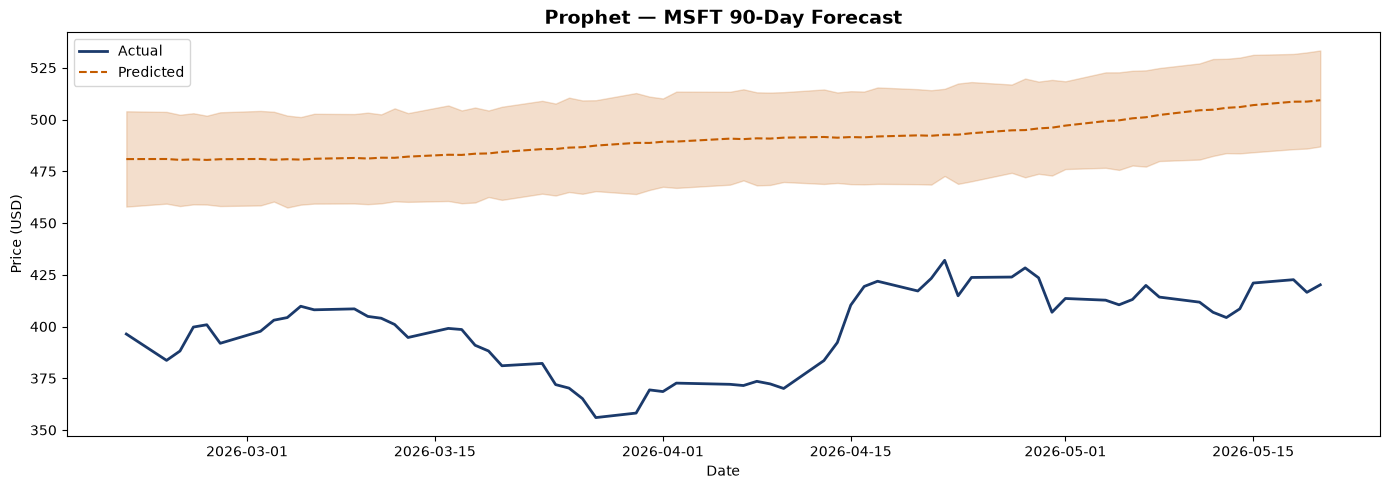

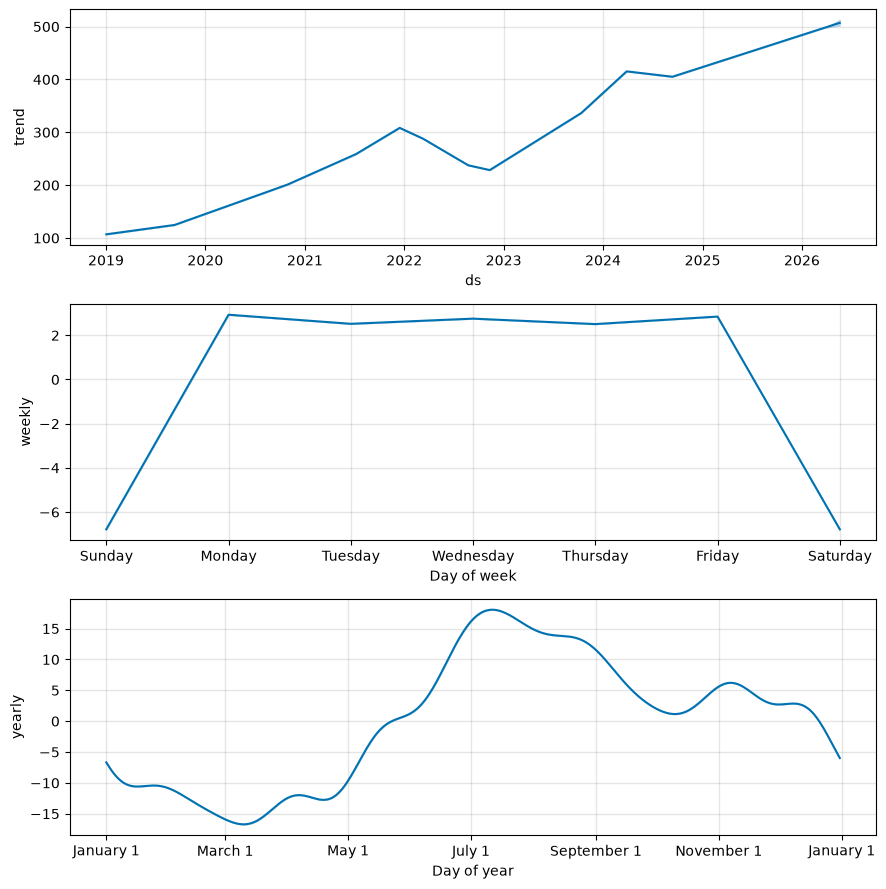


Fitting Prophet on GOOGL...
GOOGL: loaded from cache (1883 rows)


17:58:13 - cmdstanpy - INFO - Chain [1] start processing
17:58:14 - cmdstanpy - INFO - Chain [1] done processing



  Prophet — GOOGL
  RMSE               : 52.3133
  MAE                : 42.2050
  MAPE               : 11.90%
  Directional Acc.   : 58.1%


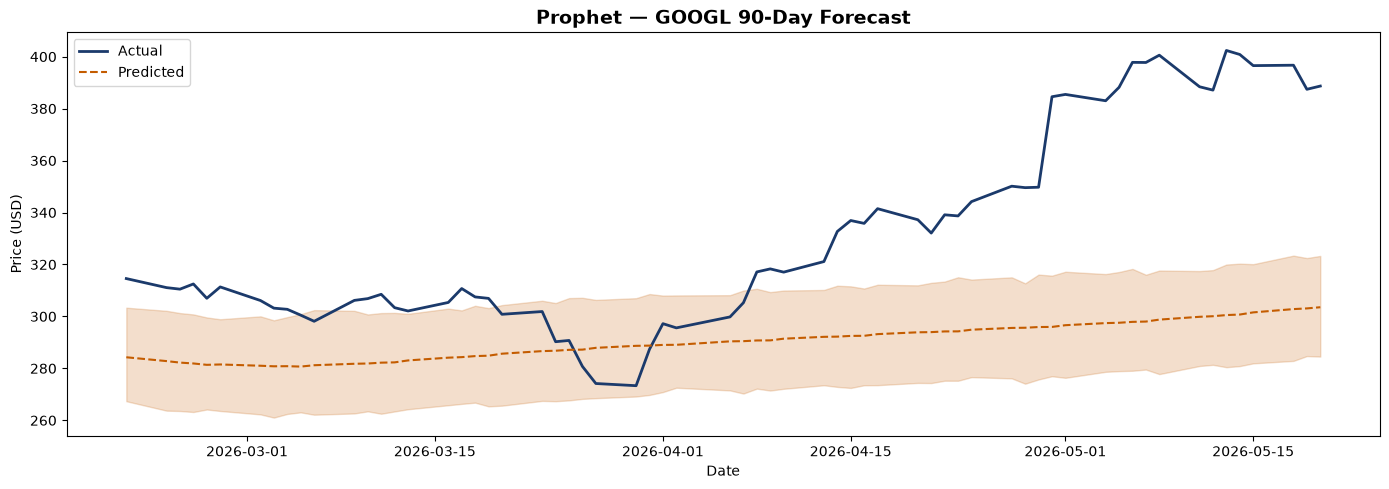

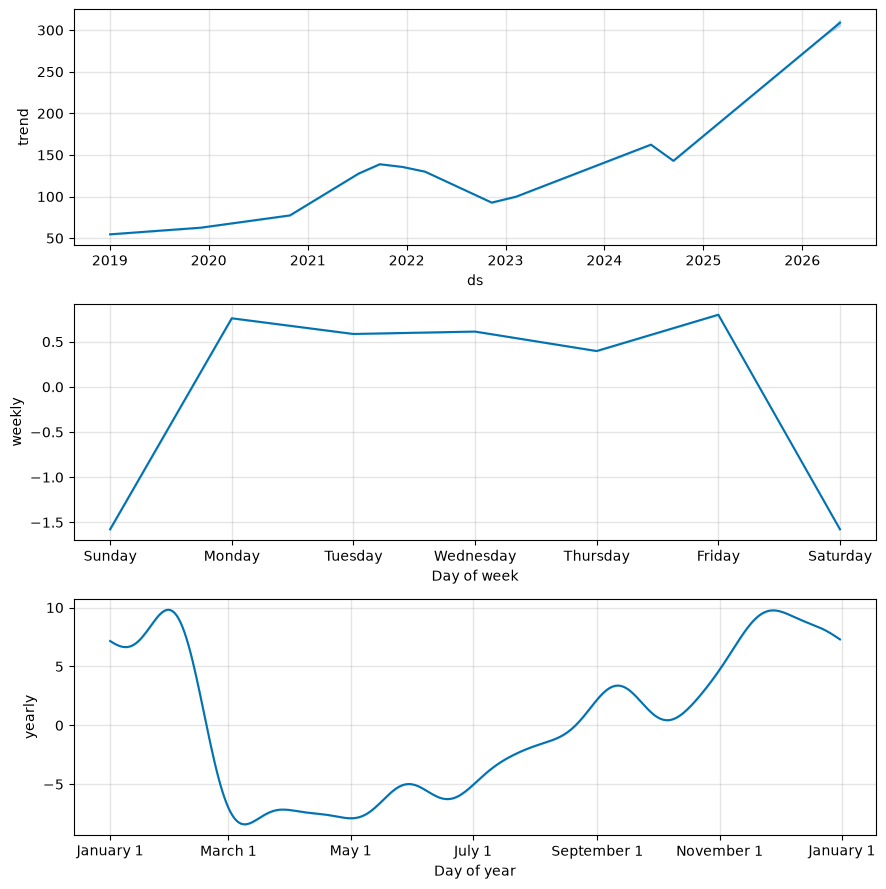


Fitting Prophet on TSLA...
TSLA: loaded from cache (1883 rows)


17:58:16 - cmdstanpy - INFO - Chain [1] start processing
17:58:16 - cmdstanpy - INFO - Chain [1] done processing



  Prophet — TSLA
  RMSE               : 48.1176
  MAE                : 41.7974
  MAPE               : 11.09%
  Directional Acc.   : 59.7%


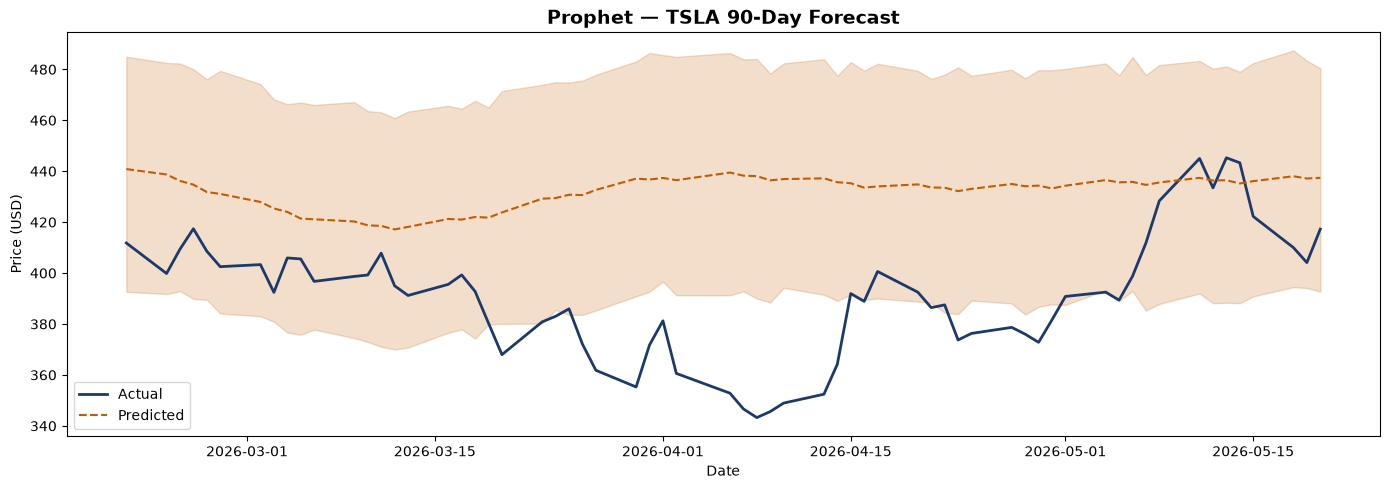

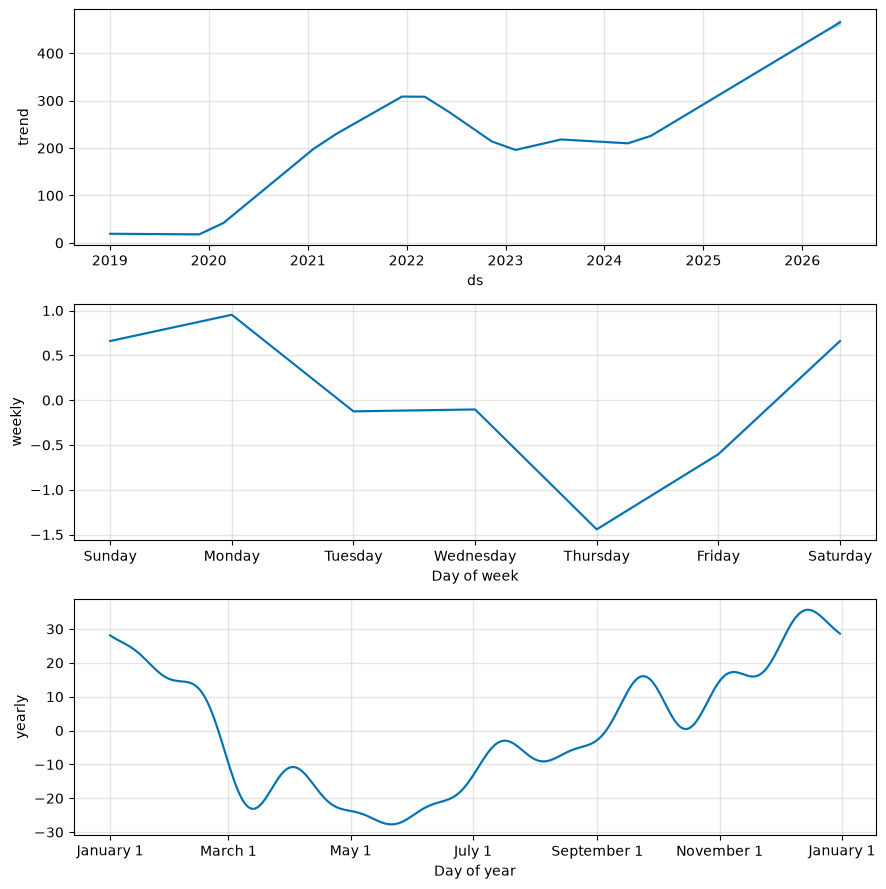


Fitting Prophet on AMZN...
AMZN: loaded from cache (1883 rows)


17:58:18 - cmdstanpy - INFO - Chain [1] start processing
17:58:19 - cmdstanpy - INFO - Chain [1] done processing



  Prophet — AMZN
  RMSE               : 24.3857
  MAE                : 22.9271
  MAPE               : 9.86%
  Directional Acc.   : 45.2%


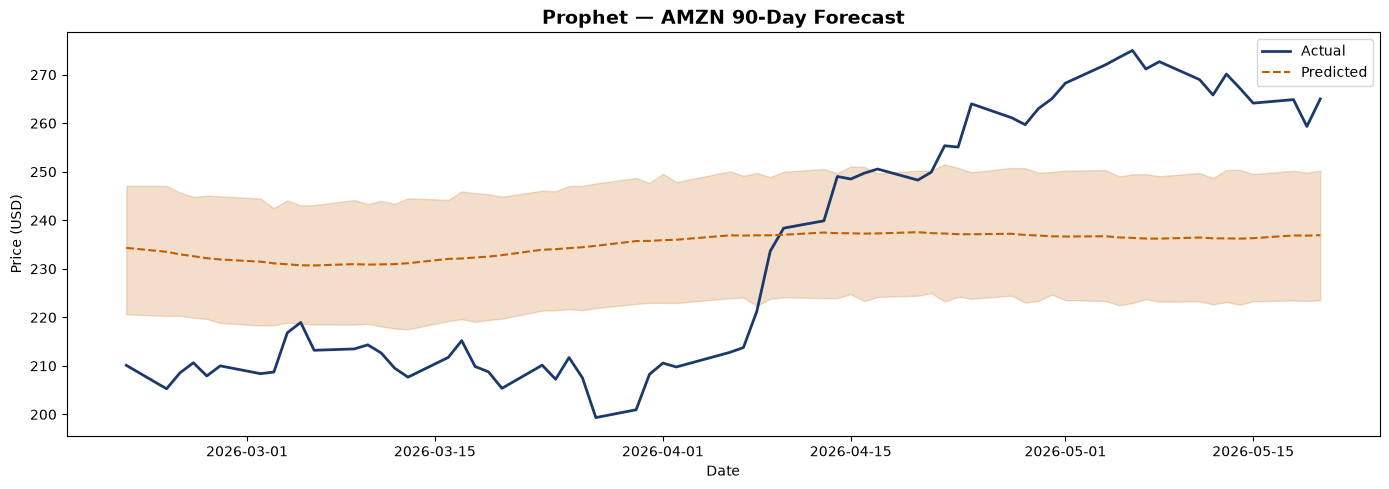

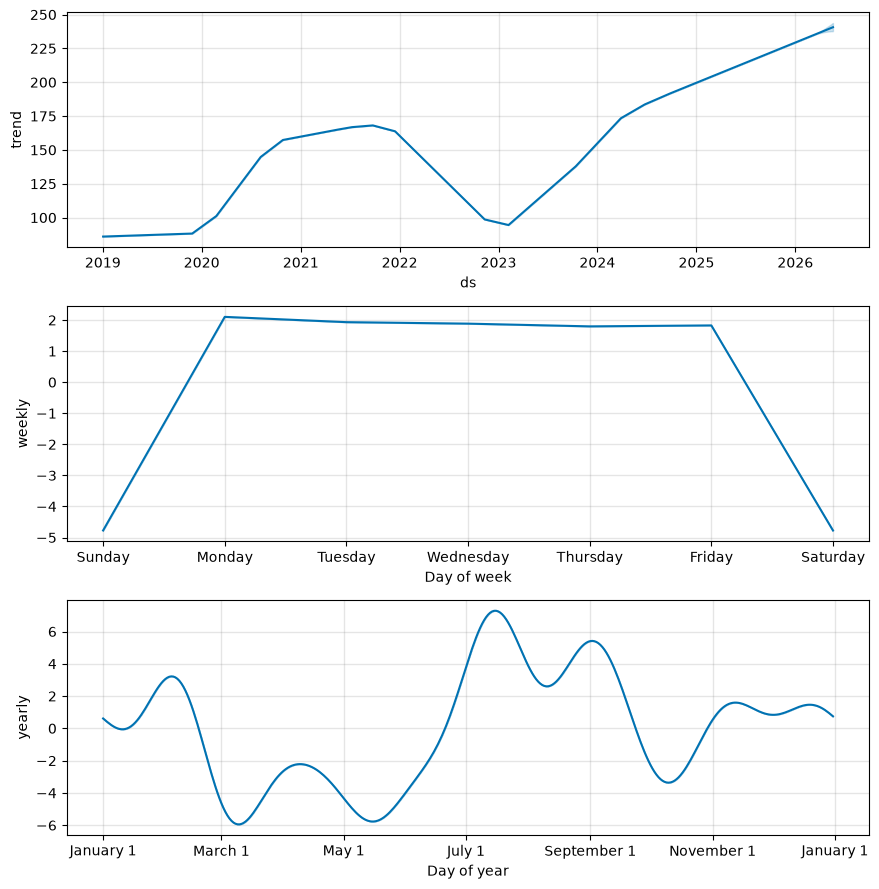


Prophet complete. Results saved.


In [1]:
import os
os.chdir(r'C:\Users\sande\Code\Personal\Python\DataScience\Project_3')

import sys
sys.path.append('..')
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from src.data_loader import fetch_ticker, TICKERS
from src.evaluate import compute_metrics, plot_predictions, save_results
import warnings
warnings.filterwarnings('ignore')
 
all_results = []
 
for ticker in TICKERS:
    print(f'\nFitting Prophet on {ticker}...')
 
    # Load data
    df = fetch_ticker(ticker)
 
    # Prophet requires columns named 'ds' (date) and 'y' (value)
    prophet_df = df[['Close']].reset_index()
    prophet_df.columns = ['ds', 'y']
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
 
    # Train/test split — last 90 days as test
    train = prophet_df[:-90]
    test  = prophet_df[-90:]
 
    # Fit model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05   # controls trend flexibility
    )
    model.fit(train)
 
    # Predict on test period
    future   = model.make_future_dataframe(periods=90)
    forecast = model.predict(future)
 
    # Extract test predictions
    test_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(
        test[['ds', 'y']], on='ds', how='inner'
    )
    y_pred = test_forecast['yhat'].values
    y_true = test_forecast['y'].values
 
    # Evaluate
    metrics = compute_metrics(y_true, y_pred, 'Prophet', ticker)
    all_results.append(metrics)
 
    # Plot actual vs predicted
    plt.figure(figsize=(14, 5))
    plt.plot(test_forecast['ds'], y_true, label='Actual',    color='#1B3A6B', lw=2)
    plt.plot(test_forecast['ds'], y_pred, label='Predicted', color='#C45C00', lw=1.5, ls='--')
    plt.fill_between(test_forecast['ds'],
                     test_forecast['yhat_lower'].values,
                     test_forecast['yhat_upper'].values,
                     alpha=0.2, color='#C45C00')
    plt.title(f'Prophet — {ticker} 90-Day Forecast', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'outputs/figures/prophet_{ticker}.png', dpi=150)
    plt.show()
 
    # Component plot — shows trend vs seasonality
    fig2 = model.plot_components(forecast)
    fig2.savefig(f'outputs/figures/prophet_components_{ticker}.png', dpi=150)
    plt.show()
 
# Save results
prophet_results_df = pd.DataFrame(all_results)
prophet_results_df.to_csv('outputs/results/prophet_results.csv', index=False)
print('\nProphet complete. Results saved.')
